# Maze Gymnasium

In [2]:
import os, sys, pickle, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import colors as mcolors
from IPython.display import display, clear_output
import ipywidgets as widgets

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

os.environ['SDL_VIDEODRIVER'] = 'dummy'
os.environ['SDL_AUDIODRIVER'] = 'dummy'

from maze_env import MazeEnv, GRID, generate_maze

N_KEYS = MazeEnv.N_KEYS
N_OBS  = GRID * GRID * (2 ** N_KEYS)
N_ACT  = 4

def obs_to_idx(obs):
    x, y, keys = int(obs[0]), int(obs[1]), int(obs[2])
    return y * GRID * (2**N_KEYS) + x * (2**N_KEYS) + keys

print(f'Przestrzeń stanów: {GRID}×{GRID}×2^{N_KEYS} = {N_OBS:,} stanów')
print(f'Rozmiar Q-tablicy: {N_OBS * N_ACT * 8 / 1024**2:.1f} MB')

Przestrzeń stanów: 40×40×2^10 = 1,638,400 stanów
Rozmiar Q-tablicy: 50.0 MB


## 1. Podgląd labiryntu

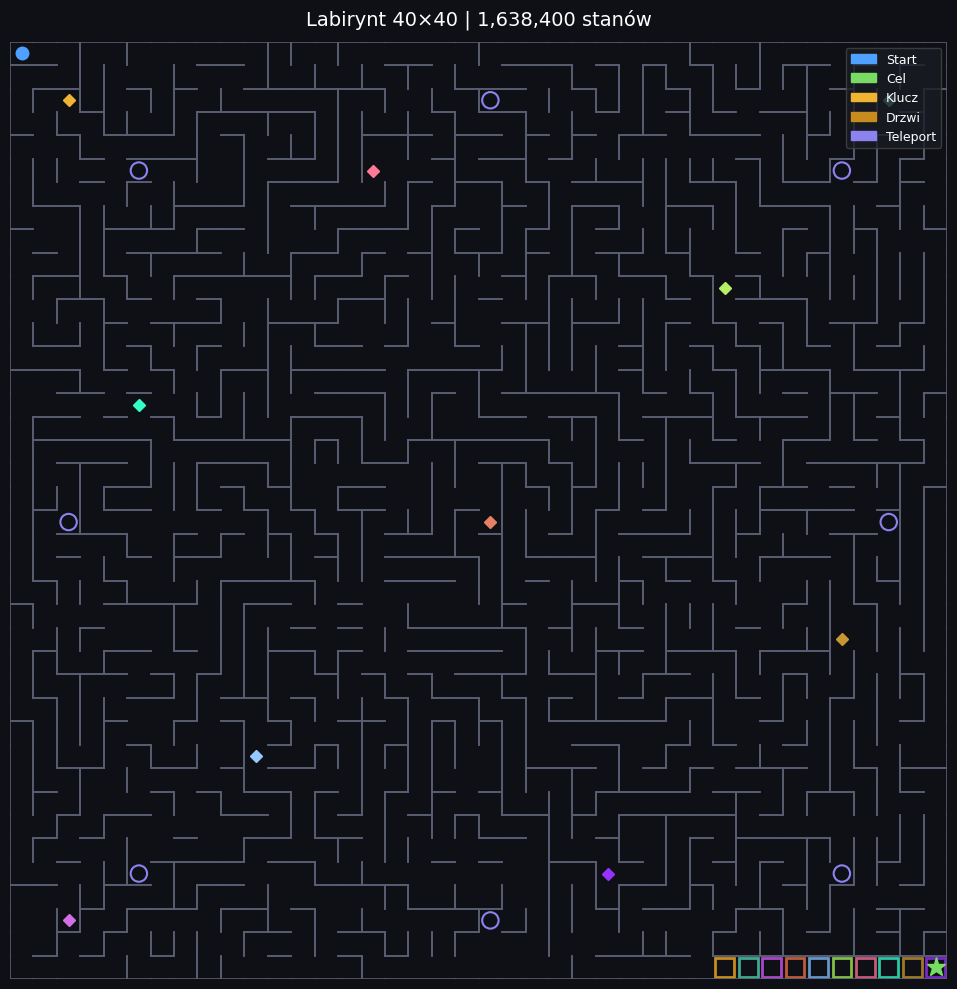

In [3]:
def draw_maze(env=None, agent_path=None, title='Labirynt'):
    if env is None:
        env = MazeEnv(render_mode=None)
        env.reset()

    walls = env.walls
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_xlim(0, GRID)
    ax.set_ylim(0, GRID)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=14, pad=12)
    ax.axis('off')

    # tło
    ax.set_facecolor('#16181f')
    fig.patch.set_facecolor('#0f1015')

    N, E, S, W = 1, 2, 4, 8
    wall_col = '#5a5e72'
    lw = 1.2

    for gy in range(GRID):
        for gx in range(GRID):
            w = walls[gy][gx]
            y_inv = GRID - 1 - gy  # odwróć oś Y
            if w & N: ax.plot([gx, gx+1], [y_inv+1, y_inv+1], color=wall_col, lw=lw)
            if w & S: ax.plot([gx, gx+1], [y_inv,   y_inv],   color=wall_col, lw=lw)
            if w & W: ax.plot([gx,   gx], [y_inv,   y_inv+1], color=wall_col, lw=lw)
            if w & E: ax.plot([gx+1, gx+1],[y_inv,  y_inv+1], color=wall_col, lw=lw)

    KEY_COLORS = ['#f0b432','#64d2b4','#d26ee6','#e68264',
                  '#96c8ff','#b4f064','#ff7896','#32ffc8','#c89632','#9632ff']
    DOOR_COLORS= ['#c88c1e','#3caa8c','#aa46c8','#be5a3c',
                  '#6496c8','#82be46','#c85a78','#28c8a0','#a07828','#7828c8']

    # teleporty
    for tp in env.TELEPORTS:
        for pos in (tp['p1'], tp['p2']):
            tx, ty = pos
            y_inv = GRID - 1 - ty
            circ = plt.Circle((tx+0.5, y_inv+0.5), 0.35, color='#8c82f0', fill=False, lw=1.5)
            ax.add_patch(circ)

    # klucze
    for k in env.KEYS:
        kx, ky = k['pos']
        y_inv = GRID - 1 - ky
        ax.plot(kx+0.5, y_inv+0.5, marker='D', markersize=6,
                color=KEY_COLORS[k['id']], zorder=3)

    # drzwi
    for d in env.DOORS:
        dx, dy = d['pos']
        y_inv = GRID - 1 - dy
        rect = mpatches.Rectangle((dx+0.1, y_inv+0.1), 0.8, 0.8,
                                   fill=False, edgecolor=DOOR_COLORS[d['key']], lw=2)
        ax.add_patch(rect)

    # cel
    gx, gy = env.GOAL
    y_inv = GRID - 1 - gy
    ax.plot(gx+0.5, y_inv+0.5, marker='*', markersize=14, color='#78dc64', zorder=4)

    # start
    sx, sy = env.START
    y_inv_s = GRID - 1 - sy
    ax.plot(sx+0.5, y_inv_s+0.5, marker='o', markersize=9, color='#50a0ff', zorder=4)

    # ścieżka agenta
    if agent_path and len(agent_path) > 1:
        xs = [p[0]+0.5 for p in agent_path]
        ys = [GRID - 1 - p[1] + 0.5 for p in agent_path]
        ax.plot(xs, ys, '-', color='#ff9632', alpha=0.7, lw=1.5, zorder=2)
        ax.plot(xs[-1], ys[-1], 'o', color='#ff9632', markersize=7, zorder=5)

    legend_elems = [
        mpatches.Patch(color='#50a0ff', label='Start'),
        mpatches.Patch(color='#78dc64', label='Cel'),
        mpatches.Patch(color='#f0b432', label='Klucz'),
        mpatches.Patch(color='#c88c1e', label='Drzwi'),
        mpatches.Patch(color='#8c82f0', label='Teleport'),
    ]
    if agent_path:
        legend_elems.append(mpatches.Patch(color='#ff9632', label='Ścieżka agenta'))
    ax.legend(handles=legend_elems, loc='upper right',
              facecolor='#1a1c24', edgecolor='#444', labelcolor='white', fontsize=9)

    plt.tight_layout()
    plt.show()

env_preview = MazeEnv(render_mode=None)
env_preview.reset()
draw_maze(env_preview, title=f'Labirynt {GRID}×{GRID} | {N_OBS:,} stanów')

## 2. Trening Q-learning

In [4]:

EPISODES    = 80000
ALPHA       = 0.3
GAMMA       = 0.95
EPS_START   = 1.0
EPS_MIN     = 0.05
PLOT_EVERY  = 10000
QTABLE_PATH = 'qtable.pkl'

print(f'Epizodów: {EPISODES}')
print(f'Alpha={ALPHA}, Gamma={GAMMA}')
print(f'Eps: {EPS_START} → {EPS_MIN}')
print(f'Podgląd co: {PLOT_EVERY} epizodów')

Epizodów: 80000
Alpha=0.3, Gamma=0.95
Eps: 1.0 → 0.05
Podgląd co: 10000 epizodów


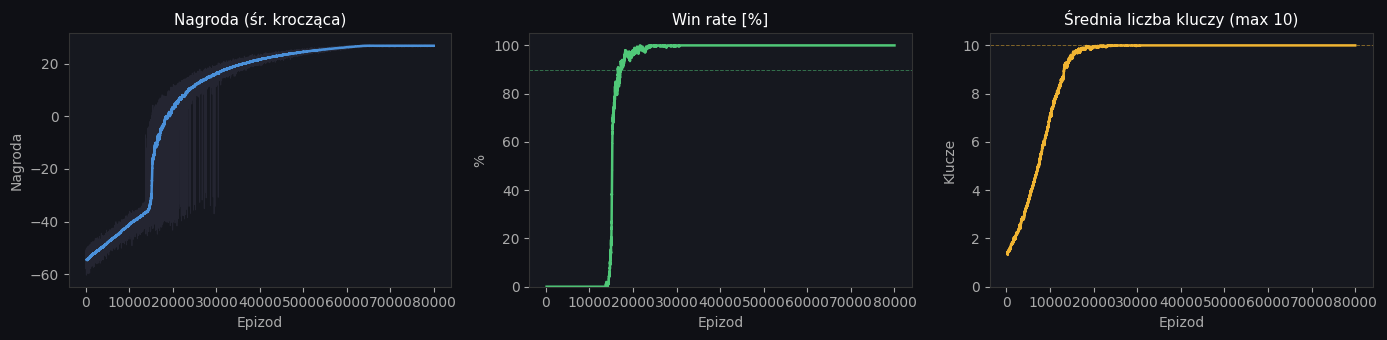


Trening zakończony! Q-tablica zapisana → qtable.pkl
Czas treningu: 907.8s
Win rate (ostatnie 500 ep.): 100.0%


In [5]:
def train_with_progress(episodes=EPISODES, alpha=ALPHA, gamma=GAMMA,
                         eps_start=EPS_START, eps_min=EPS_MIN,
                         plot_every=PLOT_EVERY, save_path=QTABLE_PATH):

    env = MazeEnv(render_mode=None)
    Q   = np.zeros((N_OBS, N_ACT), dtype=np.float32)
    eps = eps_start
    eps_dec = (eps_start - eps_min) / (episodes * 0.8)

    rewards_hist  = []
    success_hist  = []
    steps_hist    = []
    keys_hist     = []

    # widgety progress
    progress = widgets.IntProgress(value=0, min=0, max=episodes,
                                   description='Trening:',
                                   bar_style='info', style={'bar_color': '#4a90d9'},
                                   layout=widgets.Layout(width='100%'))
    status = widgets.HTML(value='<i>Inicjalizacja...</i>')
    display(widgets.VBox([progress, status]))

    t0 = time.time()

    for ep in range(episodes):
        obs, _ = env.reset()
        total_r = 0.0
        done    = False

        while not done:
            s = obs_to_idx(obs)
            if np.random.rand() < eps:
                action = env.action_space.sample()
            else:
                action = int(np.argmax(Q[s]))

            obs2, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            s2   = obs_to_idx(obs2)
            Q[s, action] += alpha * (reward + gamma * np.max(Q[s2]) - Q[s, action])
            obs      = obs2
            total_r += reward

        eps = max(eps_min, eps - eps_dec)
        rewards_hist.append(total_r)
        success_hist.append(1 if terminated else 0)
        steps_hist.append(env._steps)
        keys_hist.append(bin(env._keys).count('1'))

        if (ep + 1) % plot_every == 0 or ep == episodes - 1:
            progress.value = ep + 1
            win_rate = np.mean(success_hist[-plot_every:]) * 100
            avg_r    = np.mean(rewards_hist[-plot_every:])
            avg_k    = np.mean(keys_hist[-plot_every:])
            elapsed  = time.time() - t0
            eta      = elapsed / (ep+1) * (episodes - ep - 1)
            status.value = (f'<b>Ep {ep+1}/{episodes}</b> | '
                            f'win={win_rate:.0f}% | avg_reward={avg_r:.2f} | '
                            f'avg_keys={avg_k:.1f}/{N_KEYS} | '
                            f'eps={eps:.3f} | ETA: {eta:.0f}s')

            clear_output(wait=True)
            display(widgets.VBox([progress, status]))

            fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
            fig.patch.set_facecolor('#0f1015')

            window = 200
            for ax in axes:
                ax.set_facecolor('#16181f')
                ax.tick_params(colors='#aaa')
                for spine in ax.spines.values():
                    spine.set_edgecolor('#333')

            # nagroda
            r_smooth = np.convolve(rewards_hist, np.ones(window)/window, 'valid')
            axes[0].plot(rewards_hist, color='#334', lw=0.6, alpha=0.5)
            axes[0].plot(range(window-1, len(rewards_hist)), r_smooth, color='#4a90d9', lw=1.8)
            axes[0].set_title('Nagroda (śr. krocząca)', color='white', fontsize=11)
            axes[0].set_xlabel('Epizod', color='#aaa')
            axes[0].set_ylabel('Nagroda', color='#aaa')

            # win rate
            wr_smooth = np.convolve(success_hist, np.ones(window)/window*100, 'valid')
            axes[1].plot(range(window-1, len(success_hist)), wr_smooth, color='#50c878', lw=1.8)
            axes[1].set_ylim(0, 105)
            axes[1].axhline(y=90, color='#50c878', lw=0.7, linestyle='--', alpha=0.5)
            axes[1].set_title('Win rate [%]', color='white', fontsize=11)
            axes[1].set_xlabel('Epizod', color='#aaa')
            axes[1].set_ylabel('%', color='#aaa')

            # zebrane klucze
            k_smooth = np.convolve(keys_hist, np.ones(window)/window, 'valid')
            axes[2].plot(range(window-1, len(keys_hist)), k_smooth, color='#f0b432', lw=1.8)
            axes[2].set_ylim(0, N_KEYS + 0.5)
            axes[2].axhline(y=N_KEYS, color='#f0b432', lw=0.7, linestyle='--', alpha=0.5)
            axes[2].set_title(f'Średnia liczba kluczy (max {N_KEYS})', color='white', fontsize=11)
            axes[2].set_xlabel('Epizod', color='#aaa')
            axes[2].set_ylabel('Klucze', color='#aaa')

            plt.tight_layout()
            plt.show()

    env.close()

    with open(save_path, 'wb') as f:
        pickle.dump(Q, f)
    print(f'\nTrening zakończony! Q-tablica zapisana → {save_path}')
    print(f'Czas treningu: {time.time()-t0:.1f}s')
    print(f'Win rate (ostatnie 500 ep.): {np.mean(success_hist[-500:])*100:.1f}%')
    return Q, rewards_hist, success_hist

Q, rewards, successes = train_with_progress()

## 3. Wczytaj istniejącą Q-tablicę

In [ ]:
QTABLE_PATH = 'qtable.pkl'

if os.path.exists(QTABLE_PATH):
    with open(QTABLE_PATH, 'rb') as f:
        Q = pickle.load(f)
    print(f'Wczytano Q-tablicę: {Q.shape}, rozmiar: {Q.nbytes/1024**2:.1f} MB')
    nonzero = np.count_nonzero(np.max(np.abs(Q), axis=1))
    print(f'Stany odwiedzone: {nonzero:,} / {N_OBS:,} ({nonzero/N_OBS*100:.1f}%)')
else:
    print('Brak pliku qtable.pkl — najpierw uruchom trening (sekcja 2).')

## 4. Uruchom agenta

Epizod zakończony | kroki=286 | nagroda=27.14 | sukces=True


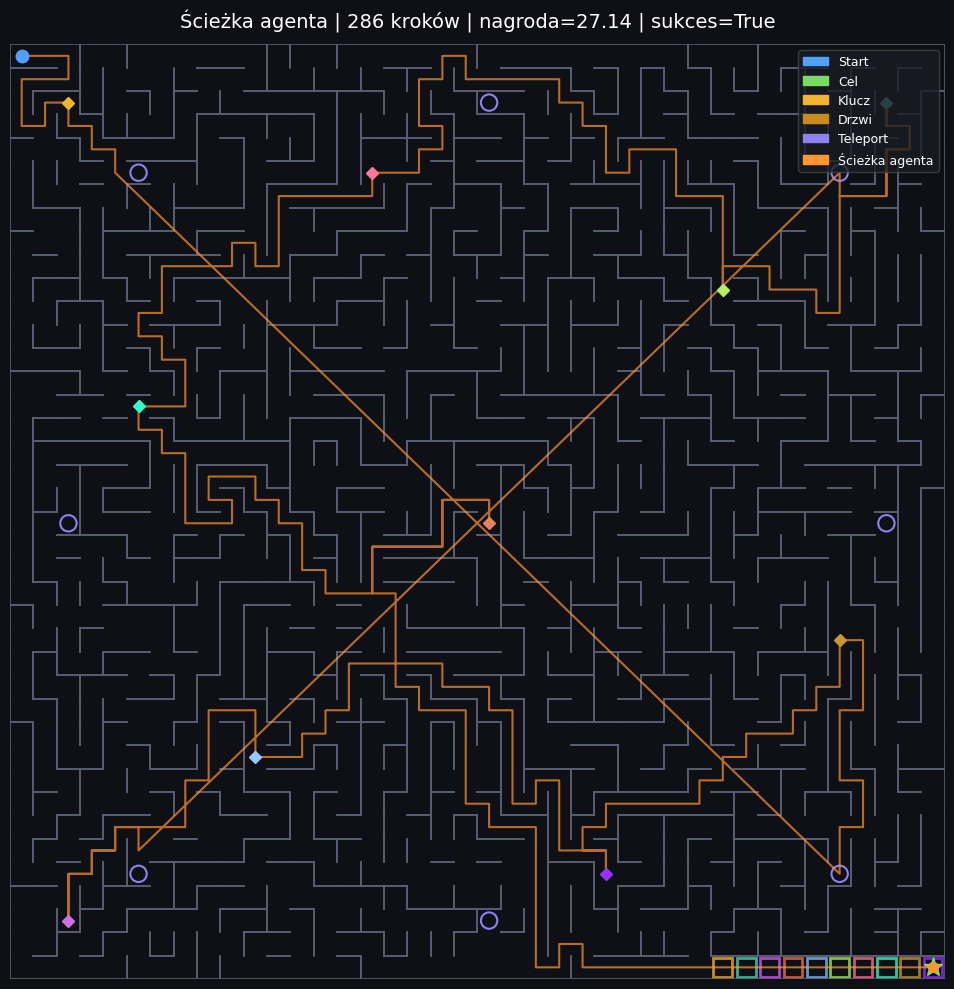


Użyj slidera żeby prześledzić ruch agenta krok po kroku:


IntSlider(value=0, description='Krok:', layout=Layout(width='80%'), max=285)

Output()

In [6]:
def run_agent_visual(Q, max_steps=500, delay=0.0):
    """Uruchamia agenta i rysuje jego ścieżkę krok po kroku na mapie."""
    env = MazeEnv(render_mode=None)
    obs, _ = env.reset()

    path   = [(env._px, env._py)]
    done   = False
    total  = 0.0
    step   = 0

    states = []
    while not done and step < max_steps:
        s      = obs_to_idx(obs)
        action = int(np.argmax(Q[s]))
        obs2, r, terminated, truncated, _ = env.step(action)
        done   = terminated or truncated
        path.append((env._px, env._py))
        states.append({
            'pos':   (env._px, env._py),
            'keys':  env._keys,
            'steps': env._steps,
            'reward': r,
            'msg':   env._message,
            'done':  terminated,
        })
        total += r
        obs    = obs2
        step  += 1

    env.close()
    success = states[-1]['done'] if states else False
    print(f'Epizod zakończony | kroki={step} | nagroda={total:.2f} | sukces={success}')

    env2 = MazeEnv(render_mode=None)
    env2.reset()
    draw_maze(env2, agent_path=path,
              title=f'Ścieżka agenta | {step} kroków | nagroda={total:.2f} | sukces={success}')

    print('\nUżyj slidera żeby prześledzić ruch agenta krok po kroku:')

    slider = widgets.IntSlider(
        value=0, min=0, max=len(states)-1, step=1,
        description='Krok:',
        continuous_update=True,
        layout=widgets.Layout(width='80%')
    )
    out = widgets.Output()

    KEY_COLORS = ['#f0b432','#64d2b4','#d26ee6','#e68264',
                  '#96c8ff','#b4f064','#ff7896','#32ffc8','#c89632','#9632ff']
    DOOR_COLORS= ['#c88c1e','#3caa8c','#aa46c8','#be5a3c',
                  '#6496c8','#82be46','#c85a78','#28c8a0','#a07828','#7828c8']

    def update_step(change):
        i = change['new']
        s = states[i]
        partial_path = path[:i+2]

        with out:
            clear_output(wait=True)
            fig, ax = plt.subplots(figsize=(10, 10))
            ax.set_facecolor('#16181f')
            fig.patch.set_facecolor('#0f1015')
            ax.set_xlim(0, GRID); ax.set_ylim(0, GRID)
            ax.set_aspect('equal'); ax.axis('off')
            bitmask = format(s['keys'], f'0{N_KEYS}b')
            ax.set_title(
                f"Krok {s['steps']} | pos=({s['pos'][0]},{s['pos'][1]}) | "
                f"keys={bitmask} | {s['msg'] if s['msg'] else ''}",
                color='white', fontsize=11
            )

            N2, E2, S2, W2 = 1, 2, 4, 8
            wc = '#5a5e72'
            env3 = MazeEnv(render_mode=None); env3.reset()
            for gy in range(GRID):
                for gx in range(GRID):
                    w = env3.walls[gy][gx]
                    yi = GRID - 1 - gy
                    if w & N2: ax.plot([gx,gx+1],[yi+1,yi+1],color=wc,lw=1)
                    if w & S2: ax.plot([gx,gx+1],[yi,yi],    color=wc,lw=1)
                    if w & W2: ax.plot([gx,gx],  [yi,yi+1],  color=wc,lw=1)
                    if w & E2: ax.plot([gx+1,gx+1],[yi,yi+1],color=wc,lw=1)

            for tp in env3.TELEPORTS:
                for pos in (tp['p1'], tp['p2']):
                    tx, ty = pos
                    circ = plt.Circle((tx+0.5, GRID-1-ty+0.5), 0.35,
                                      color='#8c82f0', fill=False, lw=1.5)
                    ax.add_patch(circ)

            for k in env3.KEYS:
                kx, ky = k['pos']
                collected = bool(s['keys'] & (1 << k['id']))
                col = KEY_COLORS[k['id']] if not collected else '#333'
                ax.plot(kx+0.5, GRID-1-ky+0.5, 'D', markersize=6, color=col)

            for d in env3.DOORS:
                dx, dy = d['pos']
                unlocked = bool(s['keys'] & (1 << d['key']))
                col = DOOR_COLORS[d['key']]
                lw2 = 1 if unlocked else 2
                rect = mpatches.Rectangle((dx+0.1, GRID-1-dy+0.1), 0.8, 0.8,
                                          fill=False, edgecolor=col, lw=lw2)
                ax.add_patch(rect)

            gx2, gy2 = env3.GOAL
            ax.plot(gx2+0.5, GRID-1-gy2+0.5, '*', markersize=14, color='#78dc64')

            if len(partial_path) > 1:
                xs = [p[0]+0.5 for p in partial_path]
                ys = [GRID-1-p[1]+0.5 for p in partial_path]
                ax.plot(xs, ys, '-', color='#ff9632', alpha=0.6, lw=1.5)

            px2, py2 = s['pos']
            ax.plot(px2+0.5, GRID-1-py2+0.5, 'o', markersize=10,
                    color='#50a0ff', zorder=5)

            plt.tight_layout()
            plt.show()

    slider.observe(update_step, names='value')
    display(slider, out)
    update_step({'new': 0})

run_agent_visual(Q)

## 5. Statystyki końcowe

=== Wyniki testu (200 epizodów) ===
Win rate:          100.0%
Śr. nagroda:       27.14 ± 0.00
Śr. kroki:         286 ± 0
Śr. zebrane klucze: 10.00 / 10


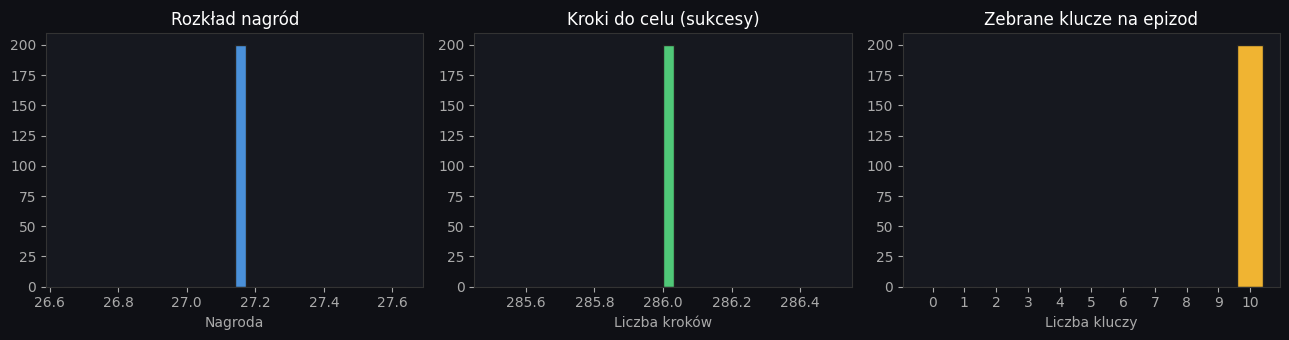

In [7]:
N_TEST = 200

env = MazeEnv(render_mode=None)
test_rewards, test_steps, test_keys, test_success = [], [], [], []

for _ in range(N_TEST):
    obs, _ = env.reset()
    done, total = False, 0.0
    while not done:
        s = obs_to_idx(obs)
        obs, r, terminated, truncated, _ = env.step(int(np.argmax(Q[s])))
        done   = terminated or truncated
        total += r
    test_rewards.append(total)
    test_steps.append(env._steps)
    test_keys.append(bin(env._keys).count('1'))
    test_success.append(1 if terminated else 0)

env.close()

print(f'=== Wyniki testu ({N_TEST} epizodów) ===')
print(f'Win rate:          {np.mean(test_success)*100:.1f}%')
print(f'Śr. nagroda:       {np.mean(test_rewards):.2f} ± {np.std(test_rewards):.2f}')
print(f'Śr. kroki:         {np.mean(test_steps):.0f} ± {np.std(test_steps):.0f}')
print(f'Śr. zebrane klucze: {np.mean(test_keys):.2f} / {N_KEYS}')

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
fig.patch.set_facecolor('#0f1015')
for ax in axes:
    ax.set_facecolor('#16181f')
    ax.tick_params(colors='#aaa')
    for sp in ax.spines.values(): sp.set_edgecolor('#333')

axes[0].hist(test_rewards, bins=30, color='#4a90d9', edgecolor='#222')
axes[0].set_title('Rozkład nagród', color='white')
axes[0].set_xlabel('Nagroda', color='#aaa')

axes[1].hist([s for s,ok in zip(test_steps, test_success) if ok],
             bins=30, color='#50c878', edgecolor='#222')
axes[1].set_title('Kroki do celu (sukcesy)', color='white')
axes[1].set_xlabel('Liczba kroków', color='#aaa')

axes[2].bar(range(N_KEYS+1),
            [test_keys.count(i) for i in range(N_KEYS+1)],
            color='#f0b432', edgecolor='#222')
axes[2].set_title('Zebrane klucze na epizod', color='white')
axes[2].set_xlabel('Liczba kluczy', color='#aaa')
axes[2].set_xticks(range(N_KEYS+1))

plt.tight_layout()
plt.show()